# VAR forecasting with Impulso

A vector autoregression (VAR) models several time series together. Each series depends on the recent past of all the series, and the random shocks to the series can be correlated. For $k$ series and $p$ lags, the vector $y_t$ of the $k$ values in quarter $t$ follows

$$
y_t = c + \sum_{l=1}^{p} A_l \, y_{t-l} + \varepsilon_t, \qquad \varepsilon_t \sim \text{MultivariateNormal}(0, \Sigma),
$$

where $c$ is a vector of intercepts, $A_l$ is the $k \times k$ matrix of coefficients for lag $l$, and $\Sigma$ is the covariance matrix of the shocks. Entry $(i, j)$ of $A_l$ gives the effect of series $j$, $l$ quarters back, on series $i$ now.

This notebook fits a VAR with two lags, VAR(2), to the quarterly growth rates of US real GDP, consumption and investment. The data are the same as in the [numpyro-forecast VAR example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/var.html). [Impulso](https://impulso.quantclimate.com/), a Bayesian VAR library built on PyMC, fits the model. pymc-forecast then evaluates the forecasts with `backtest`. The notebook has these steps:

1. Load the data and transform it to growth rates.
2. Set a Minnesota prior on the coefficients.
3. Connect Impulso to `backtest` with a small adapter class.
4. Fit the model and forecast one holdout window.
5. Evaluate the forecasts on four expanding windows.

## Prepare notebook

Impulso is not a dependency of pymc-forecast. To run this notebook, install it with the `notebooks` dependency group (`uv sync --group notebooks`) or with `pip install impulso`.

In [1]:
import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from impulso import VAR, VARData
from impulso.priors import MinnesotaPrior
from impulso.samplers import NUTSSampler
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from pymc_forecast import (
    DEFAULT_METRICS,
    backtest,
    eval_crps,
    evaluate_forecast,
    null_covariates,
    prediction_samples,
    results_to_dataframe,
    thin_draws,
)
from pymc_forecast.datasets import load_us_macro
from pymc_forecast.metrics import Metric

HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%config InlineBackend.figure_format = "retina"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)
# Impulso 0.1.3 calls `pm.sample` with `nuts_sampler_kwargs=...` and
# `idata_kwargs={"log_likelihood": True}`. PyMC 6 deprecates both arguments.
for message in ("`nuts_sampler_kwargs` is deprecated", "Passing `log_likelihood` via"):
    warnings.filterwarnings("ignore", message=message, category=FutureWarning)

SEED = 2_026
HOLDOUT = 8  # quarters per test window

# CI executes every example notebook end-to-end with reduced settings.
SMOKE_TEST = os.environ.get("PYMC_FORECAST_SMOKE_TEST", "0") == "1"
DRAWS, TUNE, CHAINS = (25, 25, 1) if SMOKE_TEST else (1_000, 1_000, 4)
NUM_SAMPLES = DRAWS * CHAINS
FOLDS = 1 if SMOKE_TEST else 4

## Read data

`load_us_macro` returns three quarterly series from the `macrodata` dataset of `statsmodels`, from 1959Q1 to 2009Q3. The data come from FRED (Federal Reserve Economic Data, Federal Reserve Bank of St. Louis) and are in the public domain. All three series are *real*: they are corrected for inflation. The unit is billions of chained 2005 US dollars, at a seasonally adjusted annual rate.

- Real GDP (`realgdp`): real gross domestic product, the total value of the goods and services that the US economy produces.
- Consumption (`realcons`): real personal consumption expenditures, the spending of households on goods and services. It is the largest part of GDP: about two thirds in these data.
- Investment (`realinv`): real gross private domestic investment, the spending of firms on equipment, software and buildings, plus the construction of new houses and the change in inventories. It is a much smaller part of GDP (about one eighth in these data), but it changes much more from quarter to quarter.

The three series move together over the business cycle. In a recession, output falls, households spend less, and firms cut investment most. Thus the recent past of one series can contain information about the next values of the others. A VAR can use this information, because each equation includes the lags of all the series.

The levels grow over time, so their mean is not constant. The VAR in this notebook assumes a constant mean, so we model the growth rates. The value $100 \cdot (\log y_t - \log y_{t-1})$ is approximately the percent change from the previous quarter. It is not annualized: the annual-rate factor of the levels cancels in the difference. Thus a value of 0.5 means approximately 0.5 percent growth in one quarter, or about 2 percent per year.

In [2]:
growth = (100 * np.log(load_us_macro())).diff("time").rename("growth")
series_names = list(growth["series"].values)
growth.to_pandas().describe().loc[["mean", "std", "min", "max"]].round(2)

series,realgdp,realcons,realinv
mean,0.78,0.84,0.81
std,0.88,0.69,4.68
min,-2.07,-2.30,-19.32
max,3.86,2.77,12.21


The standard deviation of investment growth is five to seven times that of GDP growth and consumption growth. The plot shows the same: the investment line has much larger swings. The dashed line marks the start of the last eight quarters, which the holdout section below uses.

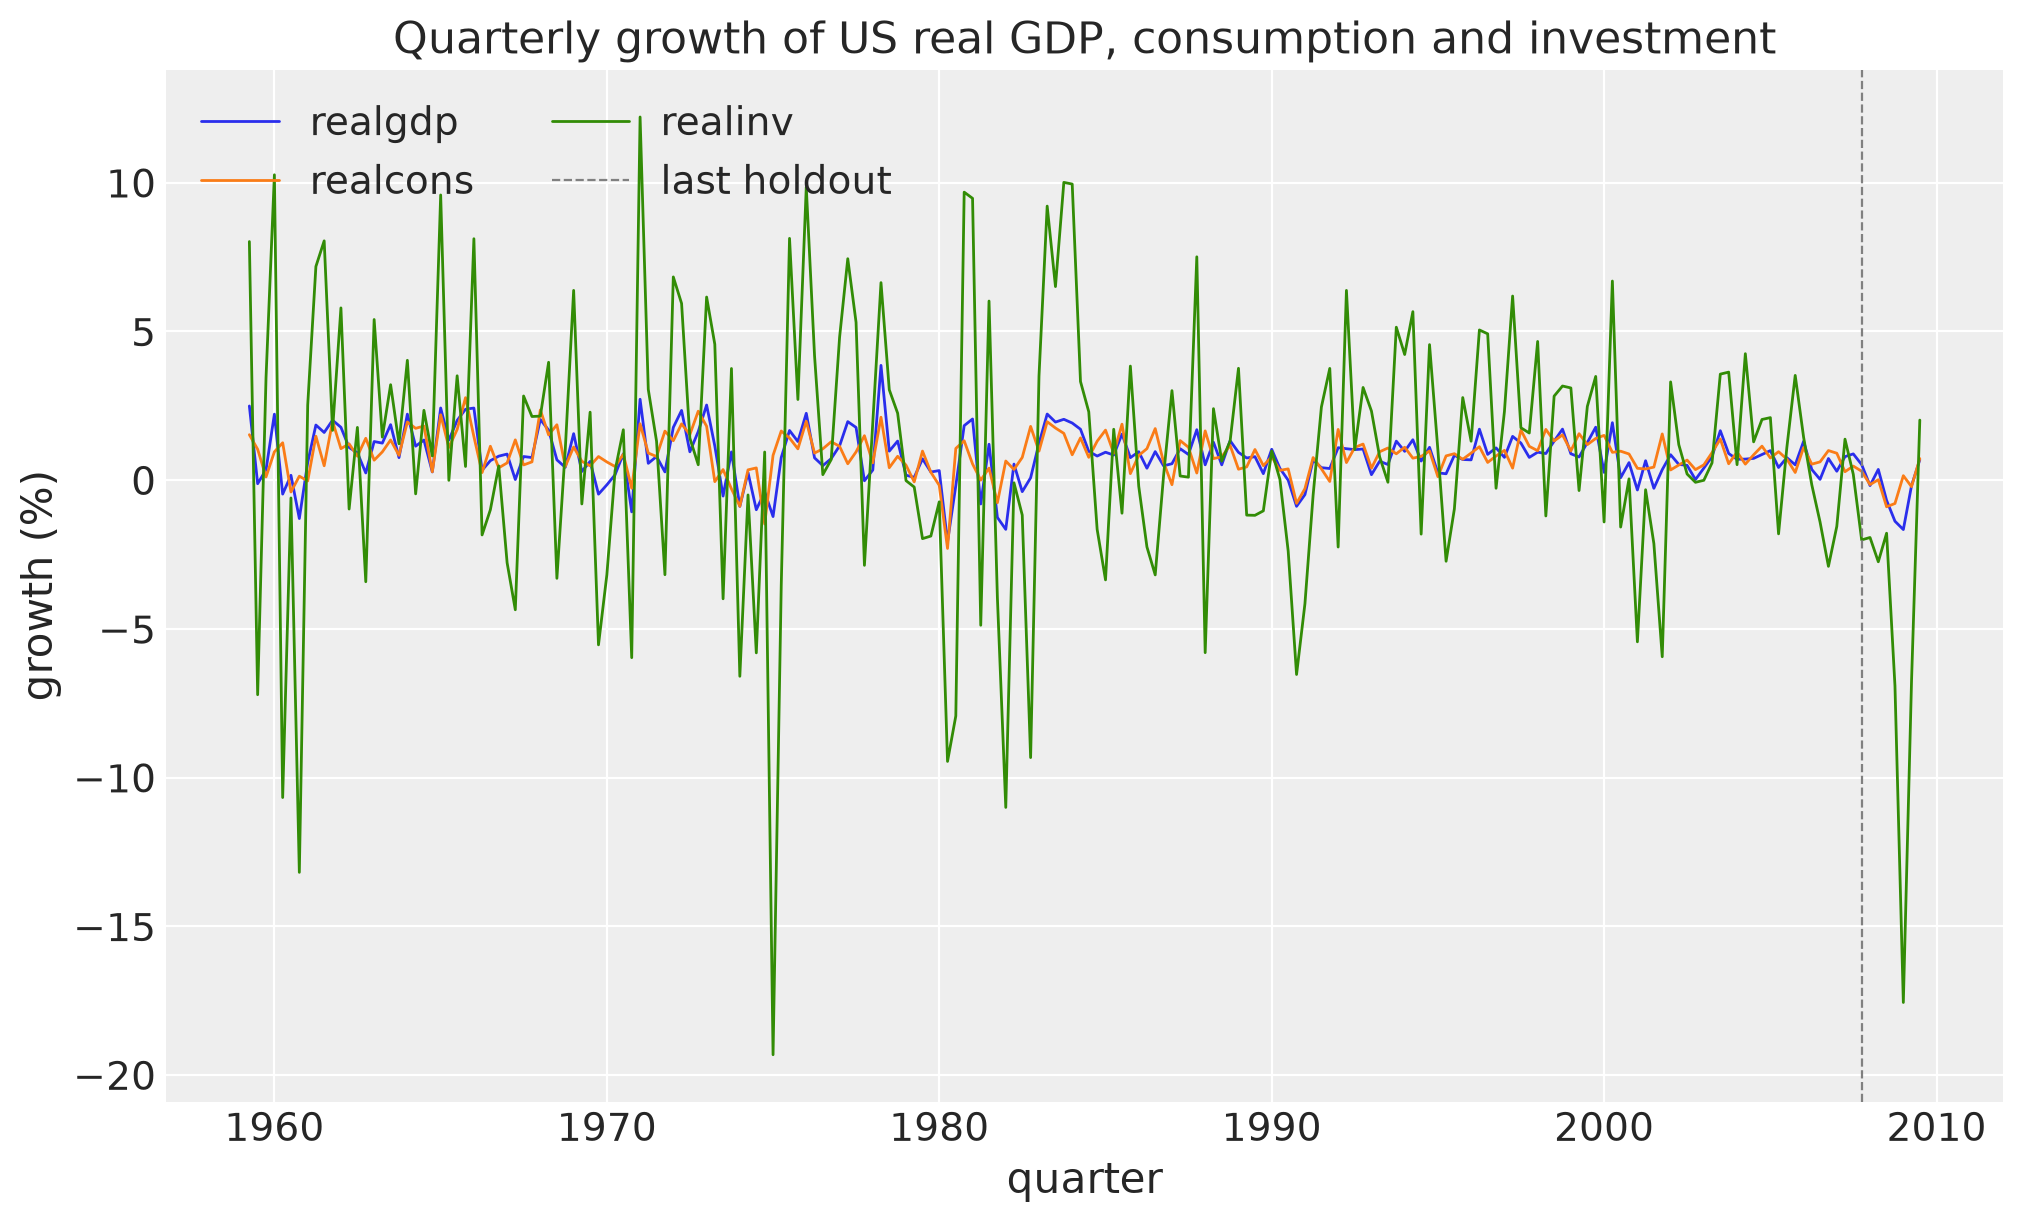

In [3]:
fig, ax = plt.subplots()
for name, color in zip(series_names, ("C0", "C1", "C2"), strict=True):
    ax.plot(growth["time"].values, growth.sel(series=name), color=color, lw=1, label=name)
ax.axvline(growth["time"].values[-HOLDOUT], color="gray", ls="--", lw=0.8, label="last holdout")
ax.legend(loc="upper left", ncol=2)
ax.set(
    title="Quarterly growth of US real GDP, consumption and investment",
    xlabel="quarter",
    ylabel="growth (%)",
);

## A Minnesota prior for growth rates

A VAR has many coefficients. Here, two lags of three series give $2 \times 3 \times 3 = 18$ lag coefficients, which the model estimates from about 200 quarters. Without a strong prior, the model can fit noise. The Minnesota prior shrinks the coefficients toward a simple model. Impulso's [Explanation: The Minnesota Prior](https://impulso.quantclimate.com/explanation/minnesota-prior.html) gives the full statement. This section gives a short version.

Write $\beta^{(l)}_{ij}$ for the coefficient of series $j$, $l$ quarters back, in the equation of series $i$ (entry $(i, j)$ of $A_l$). With the settings of this notebook, each coefficient has an independent prior

$$
\beta^{(l)}_{ij} \sim \text{Normal}\left(0, s^{(l)}_{ij}\right), \qquad s^{(l)}_{ij} = \lambda \cdot \frac{1}{l} \cdot \kappa_{ij} \cdot \frac{\sigma_i}{\sigma_j},
$$

where the second argument of $\text{Normal}$ is the standard deviation, and:

- $\lambda = 0.1$ is the overall tightness. A smaller $\lambda$ keeps all the coefficients nearer to 0.
- $1/l$ is the lag decay (`decay="harmonic"`). The prior on lag 2 has half the standard deviation of the prior on lag 1, because older values usually tell less about the next quarter.
- $\kappa_{ij}$ is 1 for the own lags of a series ($i = j$) and $\kappa = 0.5$ for the lags of the other series (`cross_shrinkage`). The prior expects a series to depend more on its own past than on the past of the other series.
- $\sigma_i$ is the residual standard deviation of an AR(1) model of series $i$, which Impulso computes from the training data. The ratio $\sigma_i / \sigma_j$ puts the coefficients on a common scale, so the prior does not depend on the units of the series. Thus you do not have to standardize the series before the fit.

Impulso's default prior puts mean 1 on the own first lag of each series ($\beta^{(1)}_{ii}$). This makes each series a random walk. That default is for series in levels, such as GDP in dollars, which trend and do not return to a fixed mean. Growth rates move around a stable mean, so this notebook sets `own_lag_mean=0.0`. Then every coefficient has prior mean 0, and the center of the prior is "each growth rate is a constant plus noise". The data must show any dependence on the past. The other settings stay at the Impulso defaults, and the two lags match the numpyro-forecast example.

In [4]:
spec = VAR(lags=2, prior=MinnesotaPrior(own_lag_mean=0.0))
spec

VAR(lags=2, max_lags=None, prior=MinnesotaPrior(tightness=0.1, decay='harmonic', cross_shrinkage=0.5, own_lag_mean=0.0), volatility='constant', exog_prior_scale=100.0, error_dist='gaussian')

## Connect Impulso to `backtest`

A pymc-forecast model (a `ForecastingModel` or a model function) puts the forecast inside the PyMC model, and `pm.sample_posterior_predictive` draws it. Impulso computes the forecast after the fit, outside the PyMC model: `FittedVAR.forecast` runs the VAR equation forward in NumPy for each posterior draw. Thus an Impulso `VAR` is not a pymc-forecast model.

`backtest` does not need one. It accepts any forecaster class with this interface:

- The constructor `forecaster_cls(model, data, covariates, random_seed=..., **options)` fits the model on the training data.
- `forecast(covariates, num_samples, random_seed)` returns an `xr.DataTree`. Its `predictions` group holds a `forecast` variable with dims `(chain, draw, time_future, series)`.

`ImpulsoForecaster` below gives Impulso this interface. The constructor converts the training data to a `VARData` object and fits the VAR with NUTS. The `forecast` method does three steps:

1. It gets the forecast quarters: the dates of `covariates` after the training window. This VAR has no covariates, so `covariates` only carries the dates (`backtest` makes them with `null_covariates`).
2. It asks Impulso for the forecast of those quarters. Each forecast sample includes two sources of uncertainty: the posterior uncertainty of the coefficients and new random shocks for each future quarter.
3. It keeps `num_samples` samples with the pymc-forecast helpers `prediction_samples` and `thin_draws`, renames Impulso's `step` and `variable` dims to `time_future` and `series`, and puts the dates on `time_future`.

The `predict_in_sample` method raises an error, because this notebook evaluates only out-of-sample forecasts.

In [5]:
class ImpulsoForecaster:
    """Fit an Impulso VAR on one window and forecast with ``FittedVAR.forecast``."""

    def __init__(
        self,
        model: VAR,
        data: xr.DataArray,
        covariates: xr.DataArray,
        *,
        random_seed: int,
        draws: int,
        tune: int,
        chains: int,
    ) -> None:
        del covariates  # only `forecast` reads the covariates (for the forecast dates)
        if not isinstance(model, VAR):
            msg = f"expected an impulso.VAR specification, got {type(model).__name__}"
            raise TypeError(msg)
        self.num_train = data.sizes["time"]
        frame = data.to_pandas()
        sampler = NUTSSampler(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=1,
            random_seed=int(random_seed),
            nuts_sampler="pymc",
            progressbar=False,
        )
        self.fitted = model.fit(VARData.from_df(frame, endog=list(frame.columns)), sampler=sampler)

    def forecast(self, covariates: xr.DataArray, num_samples: int, random_seed: int) -> xr.DataTree:
        future_time = covariates["time"].values[self.num_train :]
        result = self.fitted.forecast(steps=len(future_time), seed=int(random_seed))
        draws = thin_draws(prediction_samples(result.idata), num_samples, random_seed)["forecast"]
        forecast = draws.rename(step="time_future", variable="series").assign_coords(
            time_future=future_time
        )
        return xr.DataTree.from_dict({"predictions": forecast.to_dataset()})

    def predict_in_sample(self, num_samples: int, random_seed: int) -> xr.DataTree:
        del num_samples, random_seed
        msg = "ImpulsoForecaster scores out-of-sample forecasts only (backtest eval_train=False)"
        raise NotImplementedError(msg)

## Fit and forecast one holdout window

Fit the VAR on all quarters except the last eight, then forecast those eight quarters (2007Q4 to 2009Q3). This window contains the financial crisis and the 2008 to 2009 recession. Thus this single split is a hard test, and it does not show if the forecast intervals are calibrated in normal periods. The backtest below gives a better view.

Check the sampler before you use the results. Impulso samples the posterior with NUTS, with four independent chains. A *divergence* is a step where the sampler cannot follow the posterior accurately. A reliable fit has zero divergences. $\hat{R}$ (`r_hat`) compares the chains: values near 1 (below about 1.01) show that the chains agree.

The table is the posterior summary of the lag coefficients `B` and the intercepts. Each row is one coefficient. In `B[realinv, L1.realcons]`, the first label is the series that the equation predicts (investment), and the second label is the predictor: consumption one quarter back (`L1`; `L2` is two quarters back). This coefficient is $\beta^{(1)}_{ij}$ with $i$ = investment and $j$ = consumption. The columns `eti89_lb` and `eti89_ub` are the bounds of the central $89\%$ posterior interval.

In [6]:
train = growth.isel(time=slice(None, -HOLDOUT))
truth = growth.isel(time=slice(-HOLDOUT, None)).rename(time="time_future")
covariates = null_covariates(growth["time"].values)

forecaster = ImpulsoForecaster(
    spec, train, covariates, random_seed=SEED, draws=DRAWS, tune=TUNE, chains=CHAINS
)
idata = forecaster.fitted.idata
posterior_summary = az.summary(idata, var_names=["B", "intercept"])
print("divergences:", int(idata["sample_stats"]["diverging"].sum()))
print("max r_hat:", float(posterior_summary["r_hat"].max()))
posterior_summary

divergences: 0
max r_hat: 1.002215251987915


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"B[realgdp, L1.realgdp]",0.086,0.053,-0.0094,0.19,3611,3106,1.00,0.00088,0.00075
"B[realgdp, L1.realcons]",0.072,0.048,-0.023,0.15,3033,2452,1.00,0.00087,0.00072
"B[realgdp, L1.realinv]",-0,0.0075,-0.014,0.015,4047,2878,1.00,0.00012,0.00012
"B[realgdp, L2.realgdp]",0.039,0.035,-0.027,0.11,3394,2915,1.00,0.00061,0.00056
"B[realgdp, L2.realcons]",0.0281,0.028,-0.022,0.082,4724,3018,1.00,0.00041,0.00044
"B[realgdp, L2.realinv]",-0.0006,0.0042,-0.008,0.0077,4465,3164,1.00,6.2e-05,5.7e-05
"B[realcons, L1.realgdp]",0.032,0.0336,-0.032,0.096,4353,3597,1.00,0.00051,0.00049
"B[realcons, L1.realcons]",0.066,0.054,-0.039,0.16,3416,3123,1.00,0.00092,0.0008
"B[realcons, L1.realinv]",0.0064,0.0062,-0.0053,0.018,4753,2834,1.00,8.9e-05,0.00011
"B[realcons, L2.realgdp]",0.0062,0.0183,-0.03,0.038,4295,3143,1.00,0.00028,0.00029


Most lag coefficients stay near the prior mean of 0. The clear exception is `B[realinv, L1.realcons]`: its $89\%$ interval is far from 0. Higher consumption growth in one quarter predicts higher investment growth in the next quarter. This link between two series is information that a VAR can use and a separate model for each series cannot.

Next, draw the forecast of the eight holdout quarters and compare it with the observed values. `evaluate_forecast` computes the default metrics of pymc-forecast. Each metric is the mean over the 8 quarters and the 3 series:

- `mae`: the mean absolute error of the forecast median.
- `rmse`: the root mean squared error of the forecast mean.
- `crps`: the continuous ranked probability score (CRPS). It compares the full forecast distribution with each observed value, not only one point of the forecast. It has the units of the data (percentage points of growth), and lower is better. For a forecast with no uncertainty, the CRPS is equal to the absolute error.
- `coverage`: the fraction of observed values inside the central $90\%$ interval of the forecast. For a calibrated forecast, it is near 0.9.

In [7]:
forecast = prediction_samples(
    forecaster.forecast(covariates, num_samples=NUM_SAMPLES, random_seed=SEED + 1)
)["forecast"]
assert forecast.dims == ("chain", "draw", "time_future", "series")
pd.Series(evaluate_forecast(forecast, truth))

mae         2.687665
rmse        4.741323
crps        2.019438
coverage    0.666667
dtype: float64

## Plot helpers

The two helpers below draw one panel for each series. `plot_series_panels` draws the observed growth in black. `plot_forecast_band` draws a forecast as its median (line) and its central $50\%$ and $90\%$ intervals (dark and light bands), and a dashed line at the first forecast quarter. The $90\%$ interval is the interval that `coverage` evaluates. The figure shows the holdout forecast with the observed growth from 1995 on, so the eight forecast quarters are easy to see.

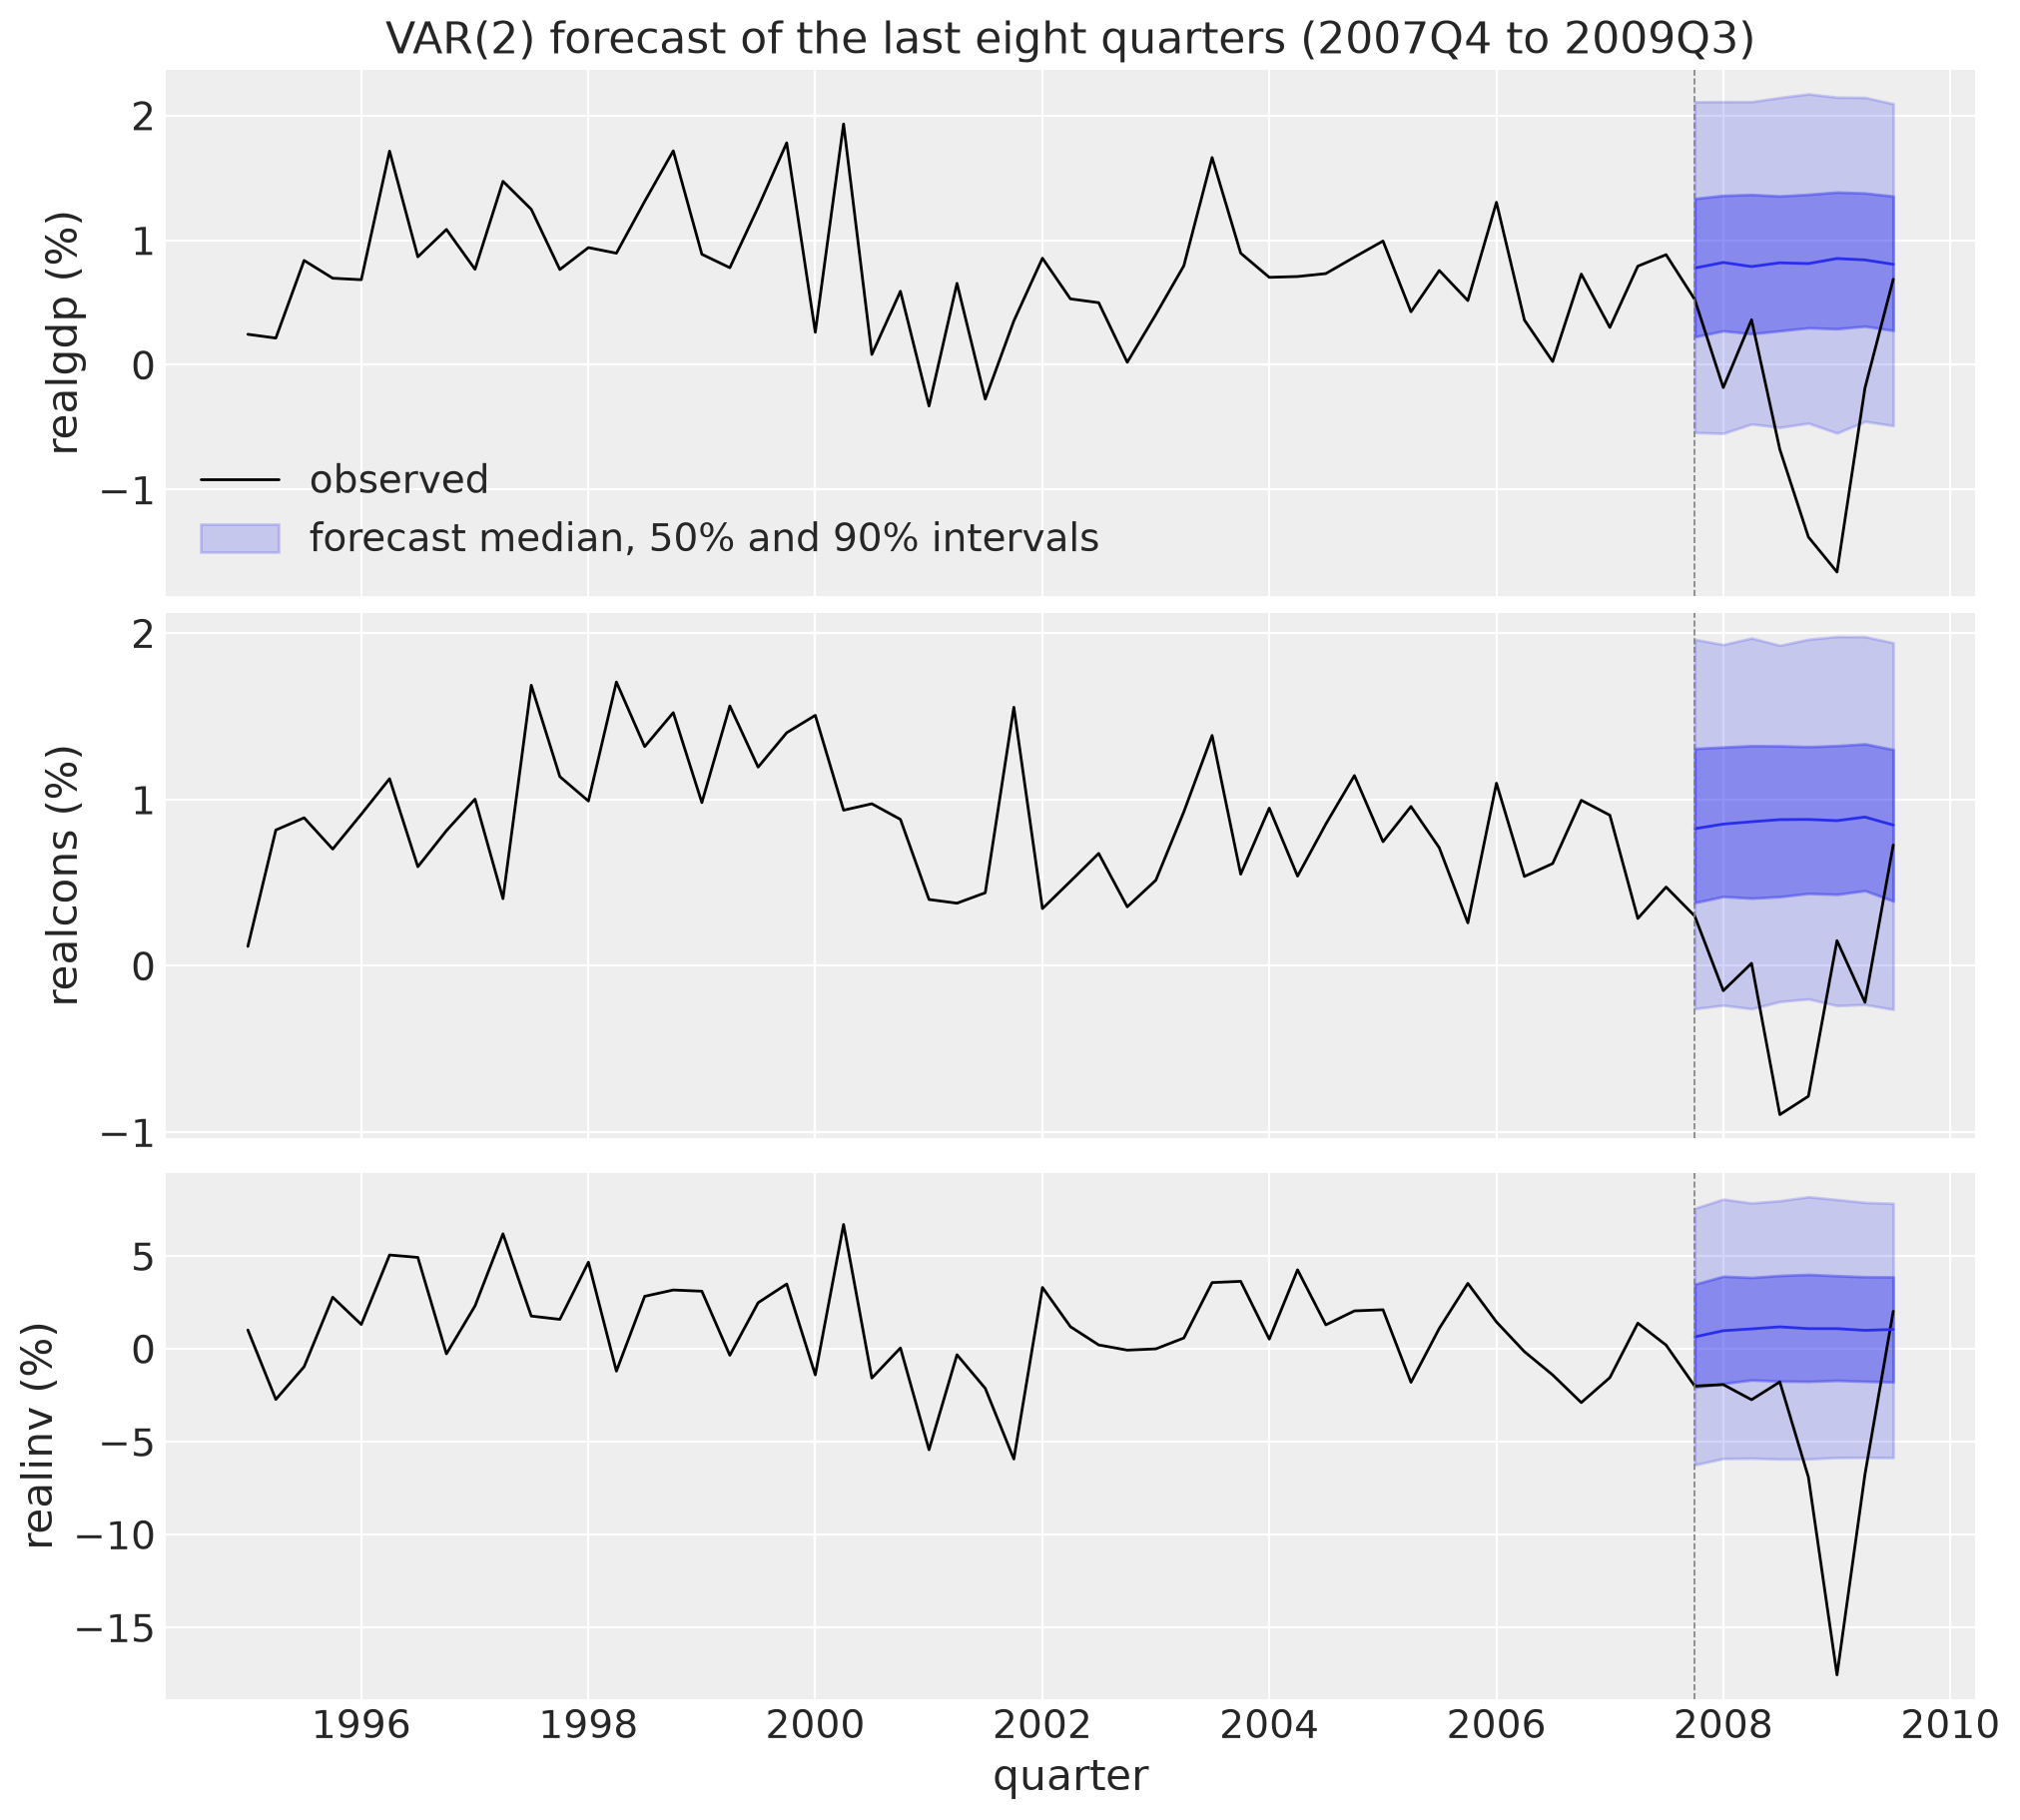

In [8]:
BAND_LABEL = r"forecast median, $50\%$ and $90\%$ intervals"


def plot_series_panels(observed: xr.DataArray, *, title: str) -> tuple[Figure, np.ndarray]:
    """One axis per series with the observed growth in black; returns ``(fig, axes)``."""
    fig, axes = plt.subplots(observed.sizes["series"], 1, figsize=(10, 9), sharex=True)
    for ax, name in zip(axes, observed["series"].values, strict=True):
        series = observed.sel(series=name)
        ax.plot(series["time"].values, series, color="black", lw=1, label="observed")
        ax.set(ylabel=f"{name} (%)")
    axes[0].set_title(title)
    axes[-1].set(xlabel="quarter")
    return fig, axes


def plot_forecast_band(
    ax: Axes, samples: xr.DataArray, *, color: str, label: str | None = None
) -> None:
    """Median and central 50% / 90% intervals of ``(chain, draw, time_future)`` samples."""
    q = samples.quantile([0.05, 0.25, 0.5, 0.75, 0.95], dim=("chain", "draw"))
    time = samples["time_future"].values
    lo, hi = q.sel(quantile=0.05), q.sel(quantile=0.95)
    ax.fill_between(time, lo, hi, color=color, alpha=0.2, label=label)
    ax.fill_between(time, q.sel(quantile=0.25), q.sel(quantile=0.75), color=color, alpha=0.4)
    ax.plot(time, q.sel(quantile=0.5), color=color, lw=1)
    ax.axvline(time[0], color="gray", ls="--", lw=0.6)


recent = growth.sel(time=slice("1995", None))
fig, axes = plot_series_panels(
    recent, title="VAR(2) forecast of the last eight quarters (2007Q4 to 2009Q3)"
)
for ax, name in zip(axes, series_names, strict=True):
    plot_forecast_band(ax, forecast.sel(series=name), color="C0", label=BAND_LABEL)
axes[0].legend(loc="lower left");

## Expanding-window backtest

One holdout window gives one noisy score. A backtest repeats the evaluation on several windows. Each repetition, a *fold*, fits the model on all quarters up to a split point and forecasts the next eight quarters. The split point then moves eight quarters forward, so each training window contains the previous one: an *expanding window*. The full run evaluates four folds, with the first forecast quarters 2001Q4, 2003Q4, 2005Q4 and 2007Q4. The last fold is the holdout window above. The CI smoke test evaluates only the last fold.

`backtest` refits the VAR in each fold with `ImpulsoForecaster` and computes the default metrics. We also give it one CRPS metric for each series (`crps_realgdp`, `crps_realcons` and `crps_realinv`), so that the table and the plot can show the score of each series.

In [9]:
def series_crps(name: str) -> Metric:
    """CRPS restricted to one series, for ``backtest(metrics=...)``."""
    return lambda pred, truth: eval_crps(pred.sel(series=name), truth.sel(series=name))


results = backtest(
    growth,
    None,
    spec,
    forecaster_cls=ImpulsoForecaster,
    forecaster_options={"draws": DRAWS, "tune": TUNE, "chains": CHAINS},
    metrics={**DEFAULT_METRICS, **{f"crps_{name}": series_crps(name) for name in series_names}},
    min_train_window=growth.sizes["time"] - FOLDS * HOLDOUT,
    test_window=HOLDOUT,
    stride=HOLDOUT,
    num_samples=NUM_SAMPLES,
    keep_predictions=True,
    random_seed=SEED + 2,
)
scores = results_to_dataframe(results)
scores

,t0,t1,t2,num_samples,train_walltime,test_walltime,mae,rmse,crps,coverage,crps_realgdp,crps_realcons,crps_realinv
0,0,170,178,4000,7.506006,0.005769,0.906577,1.597082,0.729789,1.000000,0.303543,0.281307,1.604517
1,0,178,186,4000,7.798025,0.005907,0.557351,1.018951,0.562119,1.000000,0.210542,0.189987,1.285828
2,0,186,194,4000,7.586420,0.005843,0.822877,1.299020,0.647249,1.000000,0.274584,0.238859,1.428305
3,0,194,202,4000,7.793314,0.006367,2.659651,4.712398,1.997245,0.666667,0.841235,0.690695,4.459805


The plot shows the CRPS of each fold. The black line is the `crps` column, which is the mean over the three series. The CRPS has the units of each series, so the investment line is the highest: investment growth moves the most.

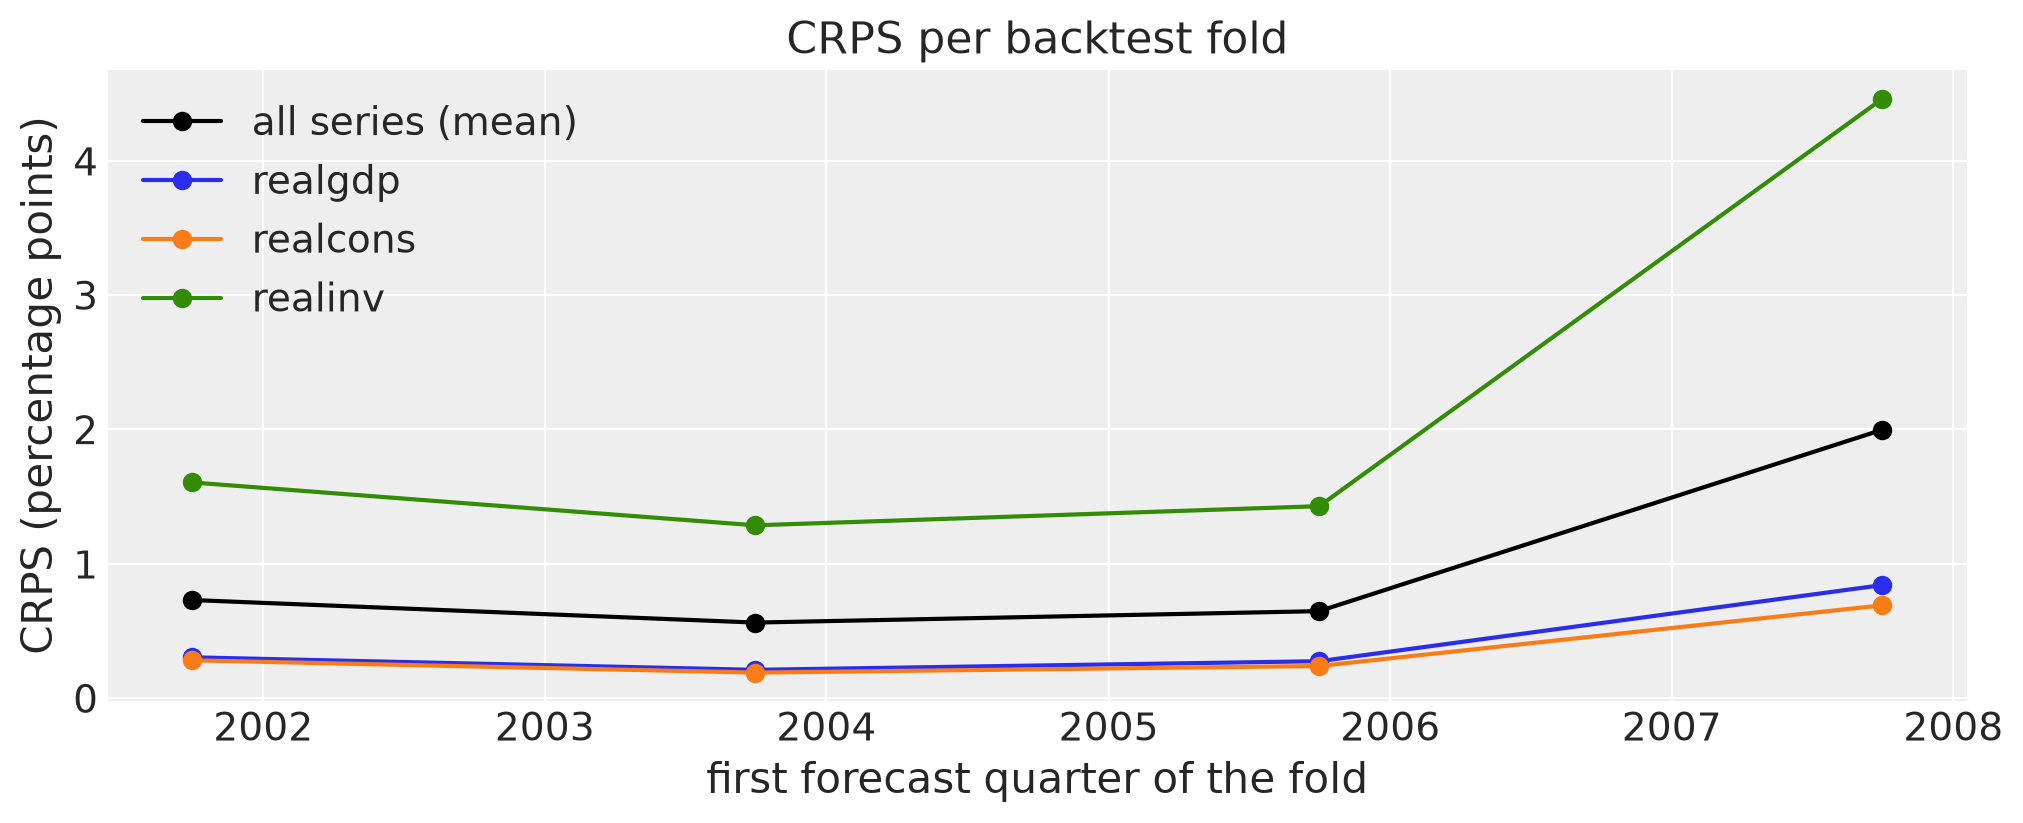

In [10]:
split_quarters = growth["time"].values[scores["t1"].to_numpy()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(split_quarters, scores["crps"], "o-", color="black", label="all series (mean)")
for name, color in zip(series_names, ("C0", "C1", "C2"), strict=True):
    ax.plot(split_quarters, scores[f"crps_{name}"], "o-", color=color, label=name)
ax.legend()
ax.set(
    xlabel="first forecast quarter of the fold",
    ylabel="CRPS (percentage points)",
    title="CRPS per backtest fold",
);

To compare the series on a common scale, divide the CRPS of each series by the standard deviation of its growth in the training window of the fold.

In [11]:
crps_columns = [f"crps_{name}" for name in series_names]
train_sd = np.stack(
    [growth.isel(time=slice(t0, t1)).std("time").values for t0, t1 in scores[["t0", "t1"]].values]
)
scaled_crps = scores[crps_columns] / train_sd
scaled_crps.index = pd.DatetimeIndex(split_quarters).to_period("Q").rename("first forecast quarter")
scaled_crps.round(2)

,crps_realgdp,crps_realcons,crps_realinv
first forecast quarter,,,
2001Q4,0.34,0.40,0.34
2003Q4,0.24,0.27,0.28
2005Q4,0.32,0.35,0.31
2007Q4,0.99,1.03,0.99


In each fold, the scaled CRPS of the three series is almost the same. Relative to its volatility, investment is not more difficult to forecast than GDP or consumption.

The last figure shows the forecasts of all folds with the observed growth from 1995 on. Each band starts at a dashed line, the first forecast quarter of its fold.

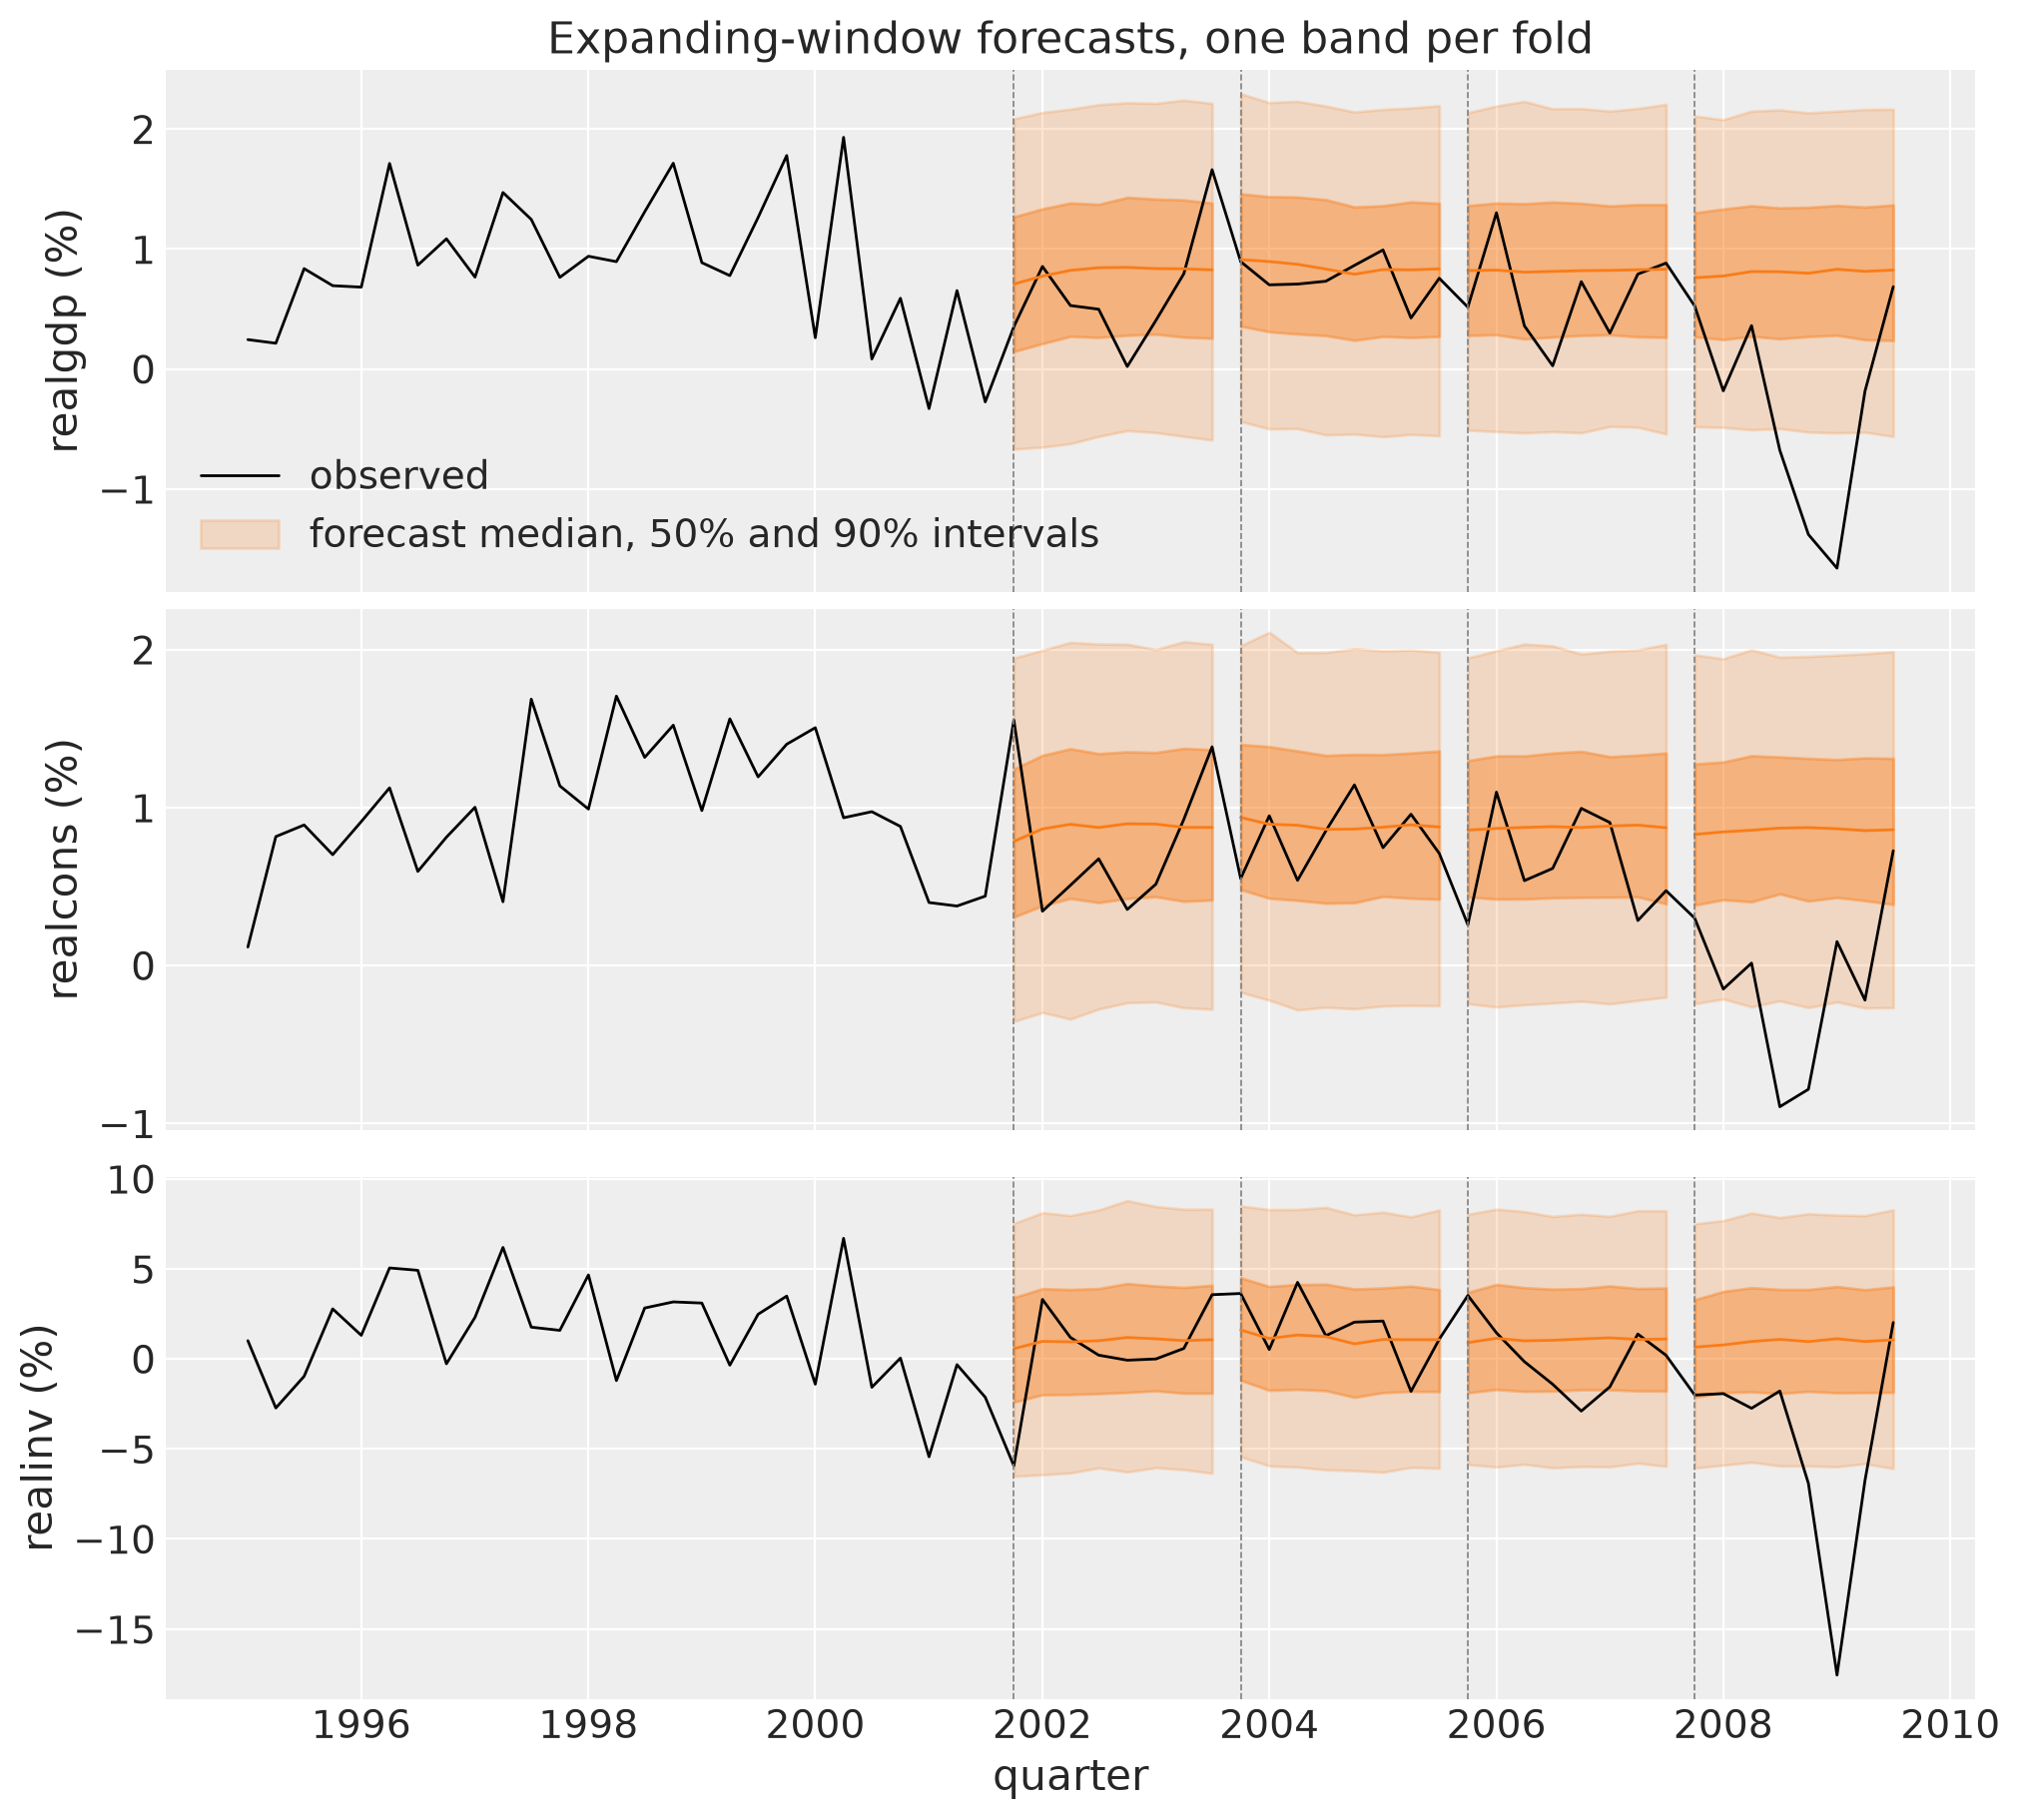

In [12]:
fig, axes = plot_series_panels(recent, title="Expanding-window forecasts, one band per fold")
for result in results:
    label = BAND_LABEL if result is results[0] else None
    for ax, name in zip(axes, series_names, strict=True):
        plot_forecast_band(ax, result.prediction.sel(series=name), color="C1", label=label)
axes[0].legend(loc="lower left");

## Summary

- **The fit is reliable.** NUTS reports no divergences, and the largest $\hat{R}$ is about 1.00, so the four chains agree. Check these two numbers again after each change to the model or the data.
- **The prior keeps the model simple.** Most lag coefficients stay near 0. The data move one coefficient far from 0: consumption growth in one quarter predicts investment growth in the next quarter. Because the other lag coefficients are small, the forecast medians are almost flat, near the average growth of each series.
- **The CRPS follows the volatility of each series.** Investment has the largest CRPS in every fold, because investment growth moves the most. Divided by the standard deviation of each series, the CRPS of the three series is almost the same. The "all series" line is the mean of the three series, so investment controls most of it.
- **The intervals are too wide in calm periods.** For a calibrated forecast, about $90\%$ of the observed values fall inside the $90\%$ interval. In the first three folds (2001Q4 to 2007Q3), all observed values fall inside. A likely cause: the model has one shock variance for the full history, and the training data start in 1959. Growth was much more volatile before 1984 than after. For example, the standard deviation of GDP growth is about 1.1 before 1984 and about 0.5 from 1984 to 2007. Each fold has only 24 values (8 quarters and 3 series), and one value changes the coverage by about 4 percentage points. Thus use the coverage of one fold only as a rough check.
- **The last fold is the financial crisis.** It forecasts 2007Q4 to 2009Q3. Its CRPS is about three times the CRPS of the earlier folds, and its $90\%$ interval contains only two thirds of the observed values. A VAR with a constant mean cannot predict a recession from the data before the recession starts. Its forecast stays near average growth, while the observed growth falls far below it.
- **Next steps.** Change the number of lags or the prior tightness (`MinnesotaPrior(tightness=...)`) and compare the backtest scores. Impulso also has Student-t shocks (`VAR(error_dist="student_t")`), which allow rare large shocks, and stochastic volatility (`VAR(volatility="sv")`), which lets the shock variance change over time. Use the same backtest to check if they improve the scores.

## References

- [Impulso documentation](https://impulso.quantclimate.com/)
- [Impulso, Explanation: The Minnesota Prior](https://impulso.quantclimate.com/explanation/minnesota-prior.html)
- [numpyro-forecast, Vector Autoregression (VAR)](https://juanitorduz.github.io/numpyro_forecast/docs/examples/var.html)
- [statsmodels, United States Macroeconomic data (`macrodata`)](https://www.statsmodels.org/stable/datasets/generated/macrodata.html)
- Litterman, R. B. (1986). Forecasting with Bayesian vector autoregressions: five years of experience. *Journal of Business & Economic Statistics*, 4(1), 25–38.